# Synthesizing Data for Healthcare Records

Highly sensitive data, such as patient health records, is challenging to analyze and share. Using SDV, you can train generative AI models on your sensitive datasets and then use them to generate synthetic data. The synthetic data mirrors the statistical patterns in your real data and even adhere to the same business logic, but synthetic data will not expose explicit information on specific individuals.

In this tutorial, we will generate synthetic data for healthcare records. We will focus on inspecting the data properties and make sure we configure the synthesizer properly to model the data.

In [1]:
import warnings

warnings.filterwarnings("ignore")

## Understanding the Data

We'll be using a dataset called [SyntheaMass](https://synthea.mitre.org/downloads), which is a multi-table, healthcare dataset containing tables on patients, payers, and more. We'll treat this dataset as our real, sensitive data, use it to train a model in the SDV, and finally use that model to generate synthetic data.

Here's a description of the tables in this dataset:

| Table               | Description                                                                                                               |
|---------------------|---------------------------------------------------------------------------------------------------------------------------|
| patients            | Patient info, including key dates, identifiers, address, and race information                                             |
| encounters          | Patients' encounters with the healthcare system (outpatient care, ambulance care, etc), including dates, payer, and cost. |
| medications         | Patients' medication history, including dates, payer, and cost.                                                           |
| careplans           | Patients' treatment plans, including dates, and type.                                                                     |
| immunizations       | Patients' immunization records, including cost and type.                                                                  |
| observations        | Patients' recorded health metrics, including type and units.                                                              |
| imaging_studies     | Imaging procedure records for patients, including procedure and modality codes.                                           |
| devices             | Issued medical devices to patients, including dates and types.                                                            |
| supplies            | Information on health supplies patients receive or use, including dates and types.                                        |
| allergies           | Patients' allergy records, including dates, severity, and type.                                                           |
| procedures          | Patients' medical procedures, including dates, codes, and reasons.                                                        |
| conditions          | Patients' medical conditions, including dates and description.                                                            |
| payers              | Payer info, including location, revenue, and amount covered.                                                              |
| payer_transitions   | Info on patients and their insurance payer over time, including dates and ownership.                                      |
| organizations       | Info on healthcare organizations, like clinics and hospitals, including location, utilization, and revenue.               |
| providers           | Info on specific clinicians, including location and utilization.                                                          |
| claims              | Info on all insurance claims on behalf of patients, including diagnoses, appointments, statuses, and billing dates.       |
| claims_transactions | Info on all payments made to settle claims, including diagnoses, appointments, and payment details.                       |


This datasets is available as a demo dataset in SDV. To load the datasets we can use the `download_demo` functionality and pass in `synthea` as the name of the dataset. The function will retrieve the dataset and its associated metadata.

Let's start by downloading the data then check that it contains 18 tables.

In [2]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(modality="multi_table", dataset_name="synthea")
list(real_data.keys())

['allergies',
 'careplans',
 'claims',
 'claims_transactions',
 'conditions',
 'devices',
 'encounters',
 'imaging_studies',
 'immunizations',
 'medications',
 'observations',
 'organizations',
 'patients',
 'payer_transitions',
 'payers',
 'procedures',
 'providers',
 'supplies']

Some columns in the data are entirely null and aren't useful for the SDV, so let's drop them.

In [3]:
null_columns_dict = {}

for name, df in real_data.items():
    null_columns = df.columns[df.isnull().all()]
    null_columns_dict[name] = null_columns.tolist()
    real_data[name].drop(columns=null_columns, inplace=True)

## Updating the Metadata
The metadata is already provided to us, but in cases where we do not have it, we can use SDV's detection functionality to create an initial version of the metadata:

```python
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(real_data)
```


If we visualize the metadata in a diagram, the complexity of the data stands out to us immediately.

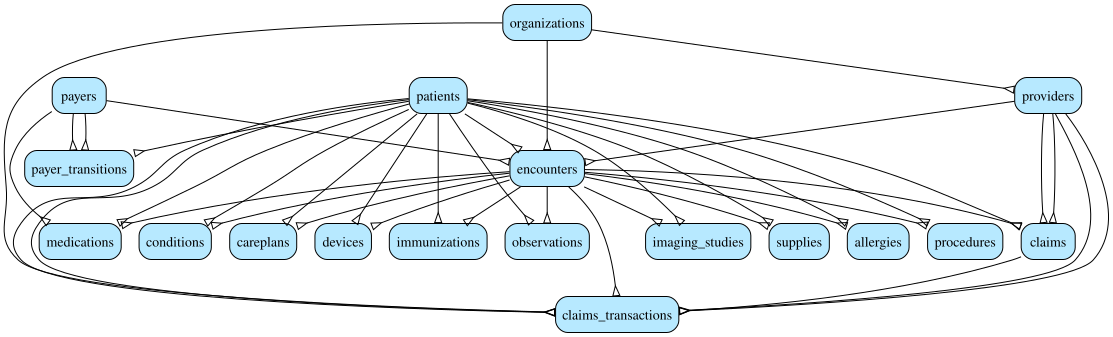

In [4]:
metadata.visualize(show_table_details=None, show_relationship_labels=False)

In [5]:
def is_composite_key(df, columns):
    subset = df[columns]
    is_unique = not subset.duplicated().any()
    return is_unique

In [6]:
is_composite_key(real_data["allergies"], ["PATIENT", "ENCOUNTER", "START", "CODE"])

True

In [7]:
is_composite_key(real_data["conditions"], ["PATIENT", "ENCOUNTER", "START", "CODE"])

True

In [8]:
is_composite_key(real_data["immunizations"], ["PATIENT", "ENCOUNTER", "DATE", "CODE"])

True

In [9]:
is_composite_key(real_data["payer_transitions"], ["PATIENT", "PAYER", "START_YEAR"])

True

In [10]:
is_composite_key(
    real_data["procedures"], ["PATIENT", "ENCOUNTER", "START", "CODE", "STOP"]
)

True

In [11]:
is_composite_key(
    real_data["supplies"], ["PATIENT", "ENCOUNTER", "DATE", "CODE", "QUANTITY"]
)

True

SDV automatically identified all of the key relationships between the tables in the data so no updates are needed here. Identifying the right sdtype automatically is much more challenging and an imperfect process, so we'll need to inspect the metadata and manually update the sdtypes if needed.


First, let's update the metadata for the `organizations` table. Majority of the fields in this table were assigned the `unknown` sdtype, which means that the SDV will have a hard time generating high quality synthetic values for these columns.

Some columns in `organizations` table with their correct sdtype:

| Column            | Correct SDType | Reason                                                                                   |
|-------------------|----------------|------------------------------------------------------------------------------------------|
| NAME              | categorical    | This will ensure the same organization names are replicated in the synthetic data.       |
| ADDRESS           | address        | SDV will know to generate realistic addresses                                            |
| ZIP               | postcode       | SDV will know to generate realistic postal codes                                         |
| LAT               | latitude       | SDV will know to generate realistic latitude values                                      |
| LON               | longitude      | SDV will know to generate realistic longitude values                                     |
| PHONE             | phone_number   | SDV will know to generate realistic phone numbers                                        |
| REVENUE           | numerical      | SDV will estimate the distribution in the real data and mirror it in the synthetic data. |

We can run the following code snippet to update our metadata to reflect these changes:



In [12]:
metadata.update_columns_metadata(
    table_name="organizations",
    column_metadata={
        "NAME": {"sdtype": "categorical"},
        "ADDRESS": {"sdtype": "address"},
        "ZIP": {"sdtype": "postcode"},
        "LAT": {"sdtype": "latitude"},
        "LON": {"sdtype": "longitude"},
        "PHONE": {"sdtype": "phone_number"},
        "REVENUE": {"sdtype": "numerical"},
    },
)

Next, let's update the `conditions` table.

| Column            | Correct SDType | Reason                                                                                       |
|-------------------|----------------|----------------------------------------------------------------------------------------------|
| START             | datetime       | Let’s specify the datetime format for SDV to use during synthesis.                           |
| STOP              | datetime       | Let’s specify the datetime format for SDV to use during synthesis.                           |
| CODE              | categorical    | The values in this column are fixed and we want SDV to replicate them in the synthetic data. |


We can run the following code snippet to update our metadata to reflect these changes:

In [13]:
metadata.update_columns_metadata(
    table_name="conditions",
    column_metadata={
        "START": {"sdtype": "datetime", "datetime_format": "%Y-%m-%d"},
        "STOP": {"sdtype": "datetime", "datetime_format": "%Y-%m-%d"},
        "CODE": {"sdtype": "categorical"},
    },
)

In addition, we will update one of the columns in the `imaging_studies` table to be `id` sdtype.

In [14]:
metadata.update_column(
    column_name="SERIES_UID",
    table_name="imaging_studies",
    sdtype="id",
)

We also need to update the metadata to remove the columns that contain no information

In [15]:
for name, columns in null_columns_dict.items():
    for column_name in columns:
        metadata.remove_column(column_name=column_name, table_name=name)

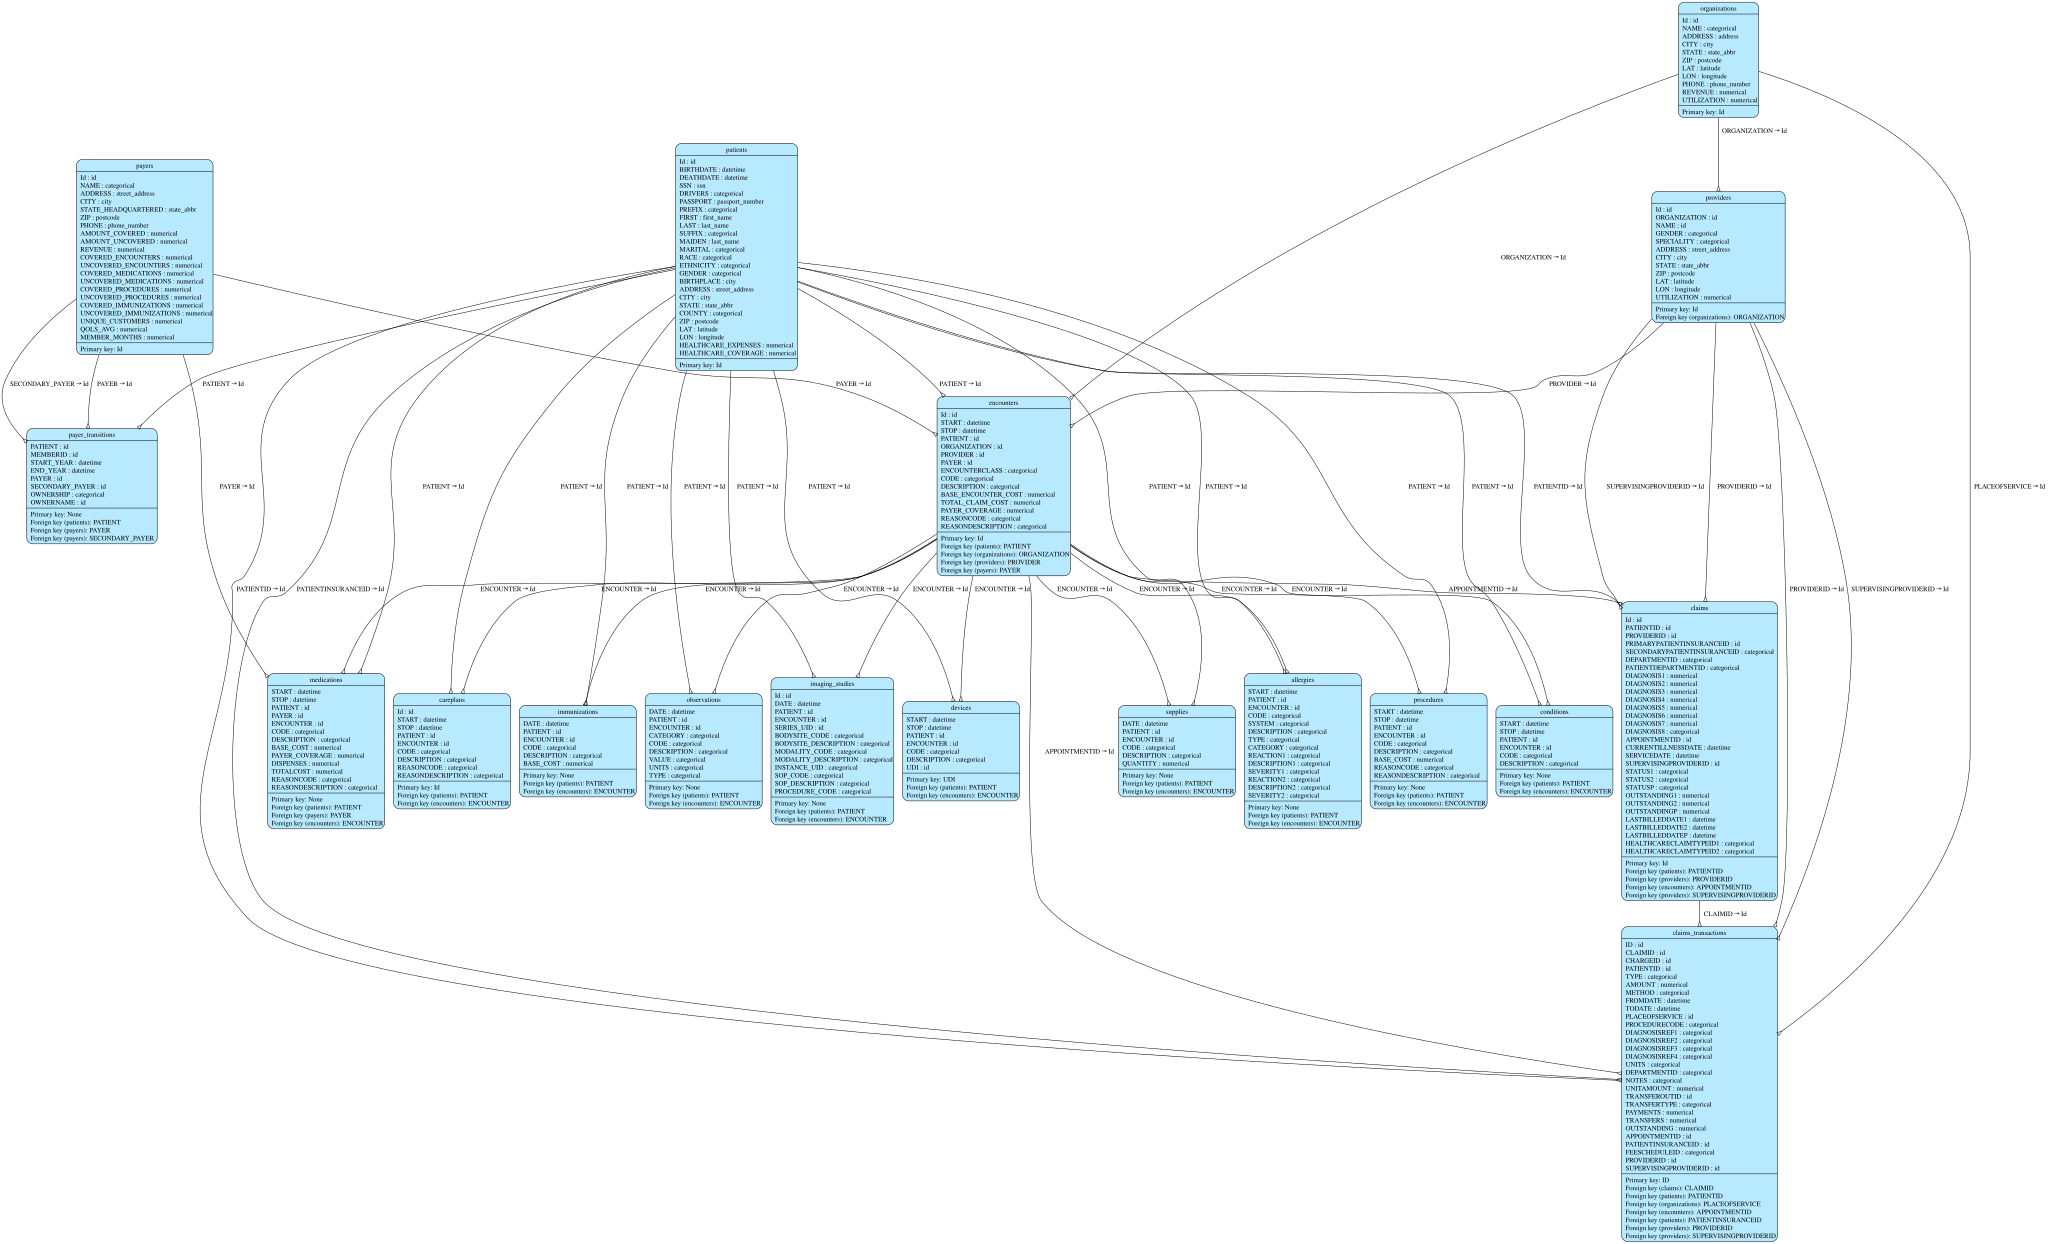

In [16]:
metadata.visualize(
    output_filepath="synthea.png",
    show_table_details=True,
    show_relationship_labels=True,
)

In [17]:
metadata.set_primary_key(
    column_name=["PATIENT", "ENCOUNTER", "START", "CODE"],
    table_name="allergies",
)

metadata.set_primary_key(
    column_name=["PATIENT", "ENCOUNTER", "START", "CODE"],
    table_name="conditions",
)

metadata.set_primary_key(
    column_name=["PATIENT", "ENCOUNTER", "DATE", "CODE"],
    table_name="immunizations",
)

metadata.set_primary_key(
    column_name=["PATIENT", "PAYER", "START_YEAR"],
    table_name="payer_transitions",
)

After you've finished modifying the metadata, let's validate the metadata. The following lines of code will validate that our metadata follows the spec that SDV expects and then will validate that the metadata accurately describes the dataset. If both validate successfully, we will see no output.

In [18]:
metadata.validate()
metadata.validate_data(real_data)

## Auto-Detecting Constraints

Constraints are deterministic rules that every row in your data must follow to be considered valid. By default, SDV synthesizers are probabilistic, so they may not learn to match these rules 100% of the time. To guarantee they hold, SDV can automatically identify common business rules in your dataset and add them as constraints.

Let's walk through a few tables, and auto-detect constraints in those tables.

### `immunizations` table

We'll start with the `immunizations` table:

In [19]:
from sdv.multi_table import HSASynthesizer

synthesizer = HSASynthesizer(metadata)
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["FixedCombinations"],
    table_names=["immunizations"],
)

Detecting constraints: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1151.96it/s]
0 Constraints Detected



In this table, SDV detected 1 FixedCombinations constraint. The values in these column groups always appear together as fixed sets.
For example, the CODE `140` is always paired with the DESCRIPTION `Influenza  seasonal  injectable  preservative free`.

In [20]:
real_data["immunizations"][["CODE", "DESCRIPTION"]].value_counts().head()

CODE  DESCRIPTION                                                                                  
140   Influenza  seasonal  injectable  preservative free                                               9538
113   Td (adult) preservative free                                                                      815
208   SARS-COV-2 (COVID-19) vaccine  mRNA  spike protein  LNP  preservative free  30 mcg/0.3mL dose     725
20    DTaP                                                                                              604
133   Pneumococcal conjugate PCV 13                                                                     559
Name: count, dtype: int64

### imaging_studies

FixedCombinations constraints can span multiple columns and the same table can have multiple, non-overlapping constraints that have to be defined. 
Let's auto-detect from the `imaging_studies` table:

In [21]:
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["FixedCombinations"],
    table_names=["imaging_studies"],
)

Detecting constraints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.73it/s]
2 Constraints Detected

0. FixedCombinations(column_names=['BODYSITE_CODE', 'BODYSITE_DESCRIPTION', 'MODALITY_CODE', 'MODALITY_DESCRIPTION'], table_name='imaging_studies')
1. FixedCombinations(column_names=['SOP_CODE', 'SOP_DESCRIPTION', 'PROCEDURE_CODE'], table_name='imaging_studies')


SDV detected 2 FixedCombinations constraints in this table. 
1. **BODYSITE_CODE**, **BODYSITE_DESCRIPTION**, **MODALITY_CODE** with **MODALITY_DESCRIPTION**: Each code always maps to the same description, and the body site and modality consistently appear together.
2. **SOP_CODE**, **SOP_DESCRIPTION**, and **PROCEDURE_CODE**, which describe the imaging procedure itself.

If we examine the columns for the first detected cosntraint, we see the following:

In [22]:
real_data["imaging_studies"][
    [
        "BODYSITE_CODE",
        "BODYSITE_DESCRIPTION",
        "MODALITY_CODE",
        "MODALITY_DESCRIPTION",
    ]
].value_counts(dropna=False)

BODYSITE_CODE  BODYSITE_DESCRIPTION                          MODALITY_CODE  MODALITY_DESCRIPTION
51185008       Thoracic structure (body structure)           CT             Computed Tomography     151094
80891009       Heart structure (body structure)              US             Ultrasound                 221
51185008       Thoracic structure (body structure)           CR             Computed Radiography       104
8205005        Wrist                                         DX             Digital Radiography         51
40983000       Arm                                           DX             Digital Radiography         43
344001         Ankle                                         DX             Digital Radiography         41
51299004       Clavicle                                      DX             Digital Radiography         36
72696002       Knee                                          DX             Digital Radiography         18
51185008       Chest                           

This table has ~151,000 rows but these columns only contain these 11 specific combinations of values. 

A similar situation can be seen by examining the **SOP_CODE** and **SOP_DESCRIPTION** columns.

In [23]:
real_data["imaging_studies"][["SOP_CODE", "SOP_DESCRIPTION"]].value_counts(dropna=False)

SOP_CODE                     SOP_DESCRIPTION                               
1.2.840.10008.5.1.4.1.1.2    CT Image Storage                                  151094
1.2.840.10008.5.1.4.1.1.3.1  Ultrasound Multiframe Image Storage                  221
1.2.840.10008.5.1.4.1.1.1.1  Digital X-Ray Image Storage                          214
                             Digital X-Ray Image Storage – for Presentation       104
1.2.840.10008.5.1.4.1.1.6.1  Ultrasound Image Storage                               4
Name: count, dtype: int64

### Auto-Detect Across All tables

If we wanted to auto-detected `FixedCombinations` constraints across every table at once, we can simply omit the `table_names` argument. SDV will then scan all tables in the dataset.

In [ ]:
synthesizer = HSASynthesizer(metadata)
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["FixedCombinations"],
)

Detecting constraints:   0%|                                                                                                                            | 0/1 [00:00<?, ?it/s]

As we can see, SDV found 22 constraints across all tables in dataset. 

Auto-detected constraints are guaranteed to be valid for your real data, but we still recommend reviewing them before adding them to the synthesizer.

Let's go ahead and add those detected constraints to our synthesizer, using the `add_constraints` method.

In [ ]:
synthesizer.add_constraints(detected_constraints)

## Manually Add Constraints

If a constraint is not auto-detected and you want to manually add the constraint, you can also do that.
Let's manually define a few constraints.

In [ ]:
from sdv.cag import FixedCombinations

## Male patients (M) only have one prefix (Mr.) while female patients have a few (Mrs. or Ms.).
patients_constraint_1 = FixedCombinations(
    column_names=["PREFIX", "GENDER"], table_name="patients"
)
conditions_constraint_1 = FixedCombinations(
    column_names=["CODE", "DESCRIPTION"], table_name="conditions"
)

claims_constraint_1 = FixedCombinations(
    column_names=["TYPE", "METHOD"], table_name="claims_transactions"
)
encounters_constraint_1 = FixedCombinations(
    column_names=["REASONCODE", "REASONDESCRIPTION"], table_name="encounters"
)

allergies_constraint_1 = FixedCombinations(
    column_names=["CODE", "DESCRIPTION"], table_name="allergies"
)
allergies_constraint_2 = FixedCombinations(
    column_names=["REACTION1", "DESCRIPTION1"], table_name="allergies"
)
allergies_constraint_3 = FixedCombinations(
    column_names=["REACTION2", "DESCRIPTION2"], table_name="allergies"
)

careplans_constraint_1 = FixedCombinations(
    column_names=["REASONCODE", "REASONDESCRIPTION"], table_name="careplans"
)

imaging_studies_constraint_1 = FixedCombinations(
    column_names=["INSTANCE_UID", "PROCEDURE_CODE"], table_name="imaging_studies"
)

Next, let's add the manually defined constraints to the synthesizer, using the `add_constraints` method.

In [ ]:
synthesizer.add_constraints(
    [
        patients_constraint_1,
        conditions_constraint_1,
        claims_constraint_1,
        encounters_constraint_1,
        allergies_constraint_1,
        allergies_constraint_2,
        allergies_constraint_3,
        careplans_constraint_1,
        imaging_studies_constraint_1,
    ]
)

## Assigning Transformers

Our dataset contains two columns that represent phone numbers. To replace them with a random phone number in the synthetic data, let's update the transformers for these columns.

First, we need to start by asking SDV to detect and establish baseline transformers using the [auto_assign_transformers()](https://docs.sdv.dev/sdv/multi-table-data/modeling/customizations/preprocessing#auto_assign_transformers) method.

In [ ]:
synthesizer.auto_assign_transformers(real_data)

Next, let's use the [update_transformers()](https://docs.sdv.dev/sdv/multi-table-data/modeling/customizations/preprocessing#update_transformers) method to update the assigned transformers for our 2 phone number columns to AnonymizedFaker.

In [ ]:
from rdt.transformers.pii import AnonymizedFaker

synthesizer.update_transformers(
    table_name="organizations",
    column_name_to_transformer={
        "PHONE": AnonymizedFaker(
            provider_name="phone_number", function_name="phone_number"
        )
    },
)

synthesizer.update_transformers(
    table_name="payers",
    column_name_to_transformer={
        "PHONE": AnonymizedFaker(
            provider_name="phone_number", function_name="phone_number"
        )
    },
)

## Generating Synthetic Data and Evaluating Quality

Let's fit the synthesizer and then sample to match the same approximate ratio of rows as our original data.

In [ ]:
synthesizer.fit(real_data)
synthetic_data = synthesizer.sample(scale=1.0)

We can use the `synthesizer.validate` method to verify that the synthetic data adheres to all applied constraints, including the `FixedCombinations` constraint.

In addition, we can use the `metadata.validate_data` to verify all tables of the metadata are present in the data.

In [ ]:
synthesizer.validate(synthetic_data)
metadata.validate_data(synthetic_data)

Next, let's generate a [quality report](https://docs.sdv.dev/sdv/multi-table-data/evaluation/data-quality) to understand how well the synthetic data mirrors the patterns in our real data.

In [ ]:
from sdv.evaluation.multi_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=real_data, synthetic_data=synthetic_data, metadata=metadata, verbose=False
)

First, let's unpack how well the SDV mirrored the distribution shapes from the real data, starting with the `patients` table.

In [ ]:
fig = quality_report.get_visualization(
    property_name="Column Shapes", table_name="patients"
)
fig.update_layout(width=1200)
fig.show()

An overall average score of 0.85 is considered very good. Let's specifically compare the distributions of the **HEALTHCARE_EXPENSES** from the patients table.

In [ ]:
from sdv.evaluation.multi_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata,
    table_name="patients",
    column_name="HEALTHCARE_EXPENSES",
    plot_type="distplot",
)
fig.update_layout(width=1200)
fig.show()

We can observe first hand how the high score from the column shapes bar plot for this table reflects the distribution similarity for this specific column. Next, let's look at the `allergies` table.

In [ ]:
fig = quality_report.get_visualization(
    property_name="Column Shapes", table_name="allergies"
)
fig.update_layout(width=1200)
fig.show()

The synthetic data in the `allergies` table also scored very high (0.95). The blue bars represent the [similarity scores](https://docs.sdv.dev/sdmetrics/metrics/metrics-glossary/tvcomplement) for the categorical columns in the real data, which were especially well recreated in the synthetic data.

## Next Steps

We generated healthcare records using SDV and evaluated its quality.
To evaluate how well your synthetic data preserves privacy of sensitive information, we can use the [CategoricalCAP](https://docs.sdv.dev/sdmetrics/metrics/metrics-glossary/categoricalcap#the-cap-algorithm) metric.

## Summary

In this tutorial, we generated synthetic data for a complex, multi-table healthcare dataset using SDV. We started by inspecting the Synthea data and cleaning out null columns, then visualized the metadata to understand the relationships across all 18 tables. We then used constraint auto-detection to find 22 business rules (constraints) in the data. A few constraints were manually added. Finally, the transformers for the phone number columns were swapped. The resulting synthetic data was evaluated and gave a quality score of `0.85`.